<div style="background:linear-gradient(135deg,#136a8a 0%,#267871 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🧫&nbsp; Allen–Cahn Equation: Bring Your Own PDE</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">The Allen–Cahn equation models phase separation — how a mixture sorts itself into distinct domains separated by thin interfaces. Here we write a <i>custom</i> PDE residual from scratch and train a PINN with a hand-rolled loop, so you can adapt the recipe to any equation you like.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#e08600;color:#fff;padding:4px 8px;">intermediate</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">custom residual</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">Allen–Cahn (reaction–diffusion)</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

In the [Burgers notebook](01_burgers_equation.ipynb) the residual came ready-made from the library.
This time we **define the physics ourselves** using `torch.autograd`, which is the skill you need to
take PINNs to your own research problem.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#physics" style="color:#1a73e8;text-decoration:none;">1 · The Allen–Cahn Equation</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#residual" style="color:#1a73e8;text-decoration:none;">3 · A Custom Residual with Autograd</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">4 · A Hand-Rolled Training Loop</a></li>
  <li style="margin:3px 0;"><a href="#dynamics" style="color:#1a73e8;text-decoration:none;">5 · Training Dynamics</a></li>
  <li style="margin:3px 0;"><a href="#solution" style="color:#1a73e8;text-decoration:none;">6 · Phase Separation in Action</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">7 · Key Takeaways</a></li>
  </ol>
</div>

<a id="physics"></a>

## 1 · The Allen–Cahn Equation

We solve the Allen–Cahn reaction–diffusion equation in the form

$$\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2} + \big(u - u^3\big),
\qquad x\in[-1,1],\; t\in[0,1],$$

with a small diffusivity $D = 5\times10^{-3}$.

- The **diffusion** term $D\,u_{xx}$ smooths the field.
- The **double-well reaction** term $u - u^3$ has stable states at $u=\pm 1$ and an unstable state at
  $u=0$, so it drives the field toward one phase or the other.

The competition produces **flat regions at $\pm 1$ joined by thin interfaces**. We start from a
smooth interface, $u(0,x)=\tanh\!\big(x/\sqrt{2D}\big)$.

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> The diffusivity \(D\) sets the interface width \(\sim\!\sqrt{2D}\). Smaller \(D\) ⇒ sharper interface, but a stiffer, harder-to-train problem.
</div>

<a id="setup"></a>

## 2 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinn").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnkit
print(f"pinn version : {pinn.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="residual"></a>

## 3 · A Custom Residual with Autograd

The heart of any PINN: a function that returns how badly the network violates the PDE. We take derivatives of the network output with `torch.autograd.grad`.

In [2]:
from torch import Tensor
from pinnkit.models import MLP

D = 5e-3                          # diffusivity (sets interface width sqrt(2D))

def allen_cahn_residual(model, t: Tensor, x: Tensor) -> Tensor:
    """Residual of  u_t - D*u_xx - (u - u^3)."""
    t = t.clone().requires_grad_(True)
    x = x.clone().requires_grad_(True)
    u = model(torch.cat([t, x], dim=1))
    grad = lambda y, v: torch.autograd.grad(y, v, torch.ones_like(y),
                                             retain_graph=True, create_graph=True)[0]
    u_t  = grad(u, t)
    u_xx = grad(grad(u, x), x)
    return u_t - D * u_xx - (u - u**3)

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> Passing <code>create_graph=True</code> is what lets us back-propagate <i>through</i> the derivatives — the network learns to make its own gradients satisfy the equation.
</div>

<a id="train"></a>

## 4 · A Hand-Rolled Training Loop

We sample fresh collocation points each step, add an initial-condition penalty, and let Adam do the work. Everything here is plain PyTorch.

In [3]:
torch.manual_seed(SEED)
model = MLP(in_dim=2, hidden_layers=4, width=40, out_dim=1).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

XMIN, XMAX, TMIN, TMAX = -1.0, 1.0, 0.0, 1.0
width = np.sqrt(2 * D)
def u0(x):                                    # initial interface
    return torch.tanh(x / width)

STEPS = 3000
hist = {"total": [], "pde": [], "ic": []}
for step in range(1, STEPS + 1):
    t = torch.rand(512, 1, device=DEVICE) * (TMAX - TMIN) + TMIN
    x = torch.rand(512, 1, device=DEVICE) * (XMAX - XMIN) + XMIN
    loss_pde = (allen_cahn_residual(model, t, x) ** 2).mean()

    x0 = torch.rand(256, 1, device=DEVICE) * (XMAX - XMIN) + XMIN
    loss_ic = ((model(torch.cat([torch.zeros_like(x0), x0], dim=1)) - u0(x0)) ** 2).mean()

    loss = loss_pde + 20.0 * loss_ic          # weight the IC so it is honoured
    opt.zero_grad(); loss.backward(); opt.step()

    hist["total"].append(loss.item()); hist["pde"].append(loss_pde.item()); hist["ic"].append(loss_ic.item())
    if step % 1000 == 0:
        print(f"step {step:5d} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | ic {loss_ic.item():.3e}")
print("Done.")

step  1000 | total 2.135e-04 | pde 1.765e-04 | ic 1.851e-06


step  2000 | total 1.161e-03 | pde 2.356e-04 | ic 4.628e-05


step  3000 | total 2.723e-03 | pde 4.758e-04 | ic 1.123e-04
Done.


<a id="dynamics"></a>

## 5 · Training Dynamics

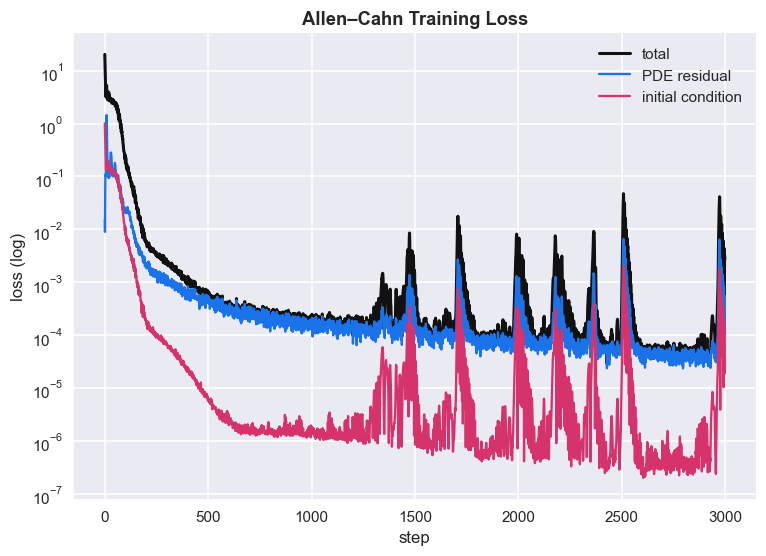

In [4]:
fig, ax = plt.subplots()
ax.plot(hist["total"], color="#111", lw=2, label="total")
ax.plot(hist["pde"],   color=ACCENT, lw=1.5, label="PDE residual")
ax.plot(hist["ic"],    color=ACCENT2, lw=1.5, label="initial condition")
ax.set_yscale("log"); ax.set(title="Allen–Cahn Training Loss", xlabel="step", ylabel="loss (log)")
ax.legend(); plt.show()

<a id="solution"></a>

## 6 · Phase Separation in Action

We evaluate the trained field and visualise the interface as it evolves in time.

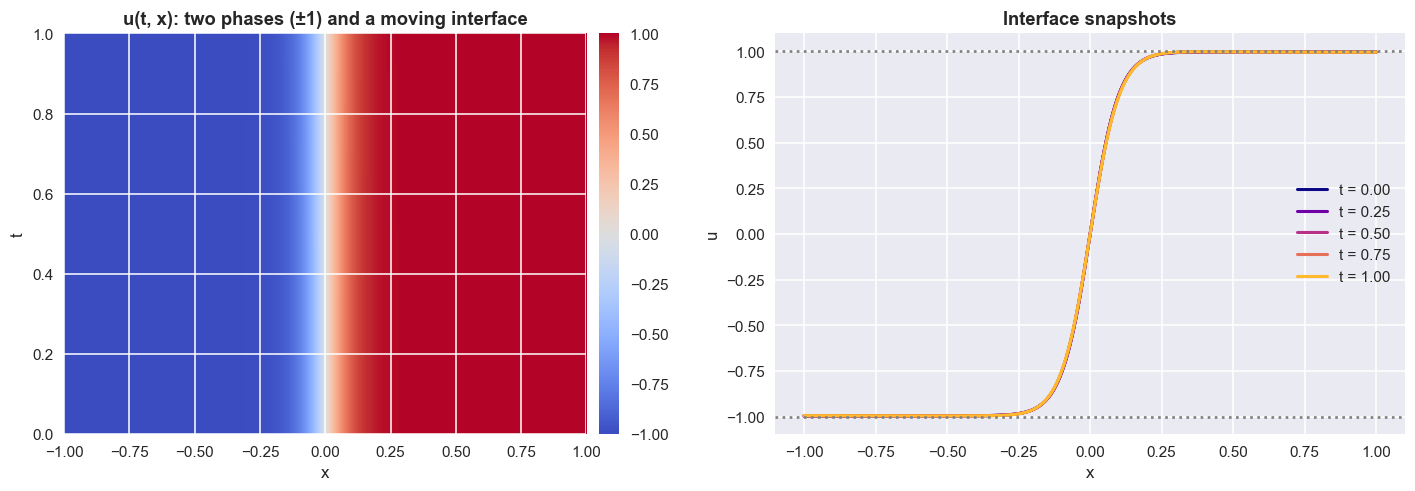

In [5]:
nt, nx = 100, 256
t_grid = np.linspace(TMIN, TMAX, nt, dtype=np.float32)
x_grid = np.linspace(XMIN, XMAX, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
with torch.no_grad():
    inp = torch.tensor(np.stack([TT.ravel(), XX.ravel()], axis=1), dtype=torch.float32, device=DEVICE)
    U = model(inp).cpu().numpy().reshape(nt, nx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
im = axes[0].imshow(U, extent=[XMIN, XMAX, TMIN, TMAX], origin="lower", aspect="auto",
                    cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set(title="u(t, x): two phases (±1) and a moving interface", xlabel="x", ylabel="t")
fig.colorbar(im, ax=axes[0], pad=0.02)

colors = plt.cm.plasma(np.linspace(0, 0.85, 5))
for t_snap, col in zip([0.0, 0.25, 0.5, 0.75, 1.0], colors):
    idx = np.argmin(np.abs(t_grid - t_snap))
    axes[1].plot(x_grid, U[idx], color=col, lw=2, label=f"t = {t_snap:.2f}")
axes[1].axhline(1, ls=":", color="gray"); axes[1].axhline(-1, ls=":", color="gray")
axes[1].set(title="Interface snapshots", xlabel="x", ylabel="u"); axes[1].legend()
plt.tight_layout(); plt.show()

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> The solution settles into the two stable phases <code>u = ±1</code> with a smooth transition layer whose width is set by <code>D</code> — exactly the behaviour the double-well reaction term encodes.
</div>

<a id="takeaways"></a>

## 7 · Key Takeaways

- Writing a **custom residual** is just a few lines of `torch.autograd.grad` — this is how you apply
  PINNs to *your* PDE.
- `create_graph=True` is the key flag that makes derivative terms differentiable.
- A hand-rolled loop gives you full control over sampling, loss weighting, and optimiser choice.
- Weighting the initial-condition term (here ×20) keeps the network anchored to the correct start.

**Next:** [`03_custom_pde`](03_custom_pde.ipynb) generalises this into a reusable template, and
[`advanced/03_inverse_problems`](../advanced/03_inverse_problems.ipynb) shows how to *learn* unknown
PDE parameters from data.

### 📚 References

1. Allen, S. M., & Cahn, J. W. (1979). *A microscopic theory for antiphase boundary motion*. Acta Metallurgica, 27(6), 1085–1095.
2. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks*. J. Comput. Phys., 378, 686–707.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>